# Rilevamento di frodi nelle transazioni con carta di credito


# 1. Introduzione del problema

Il problema consiste nel classificare una transazione come lecita oppure fraudolenta.

La variabile target e Class :

- 0: transazione lecita;
- 1: transazione fraudolenta.

Si tratta di un problema di classificazione binaria con classi molto sbilanciate. Per questo motivo, oltre all'accuracy, sono importanti precision, recall, F1-score e confusion matrix.

# 2. Descrizione del dataset

Il dataset usato e il Credit Card Fraud Detection Dataset, disponibile su Kaggle:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Il file si chiama creditcard.csv.

Il dataset contiene transazioni con carta di credito. Le variabili V1, V2, ..., V28 sono state trasformate tramite PCA, quindi non hanno un significato diretto facilmente interpretabile. Sono inoltre presenti:

- Time: tempo trascorso dalla prima transazione;
- Amount: importo della transazione;
- Class: variabile target, dove 0 indica transazione lecita e 1 indica frode.

Per eseguire il notebook, il file creditcard.csv deve trovarsi nella stessa cartella del notebook 

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

# 3. Caricamento dei dati

In questa sezione carichiamo il dataset e controlliamo le prime righe, la dimensione e la presenza di valori mancanti.

In [43]:
df = pd.read_csv("creditcard.csv")


In [44]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
df.shape, df["Class"].value_counts()

((284807, 31),
 Class
 0    284315
 1       492
 Name: count, dtype: int64)

In [20]:
print("Valori mancanti totali:", df.isna().sum().sum())
df.describe().loc[["min", "max", "mean", "std"]].T.head(15)

Valori mancanti totali: 0


,min,max,mean,std
Time,0.000000,172792.000000,9.481386e+04,47488.145955
V1,-56.407510,2.454930,1.175161e-15,1.958696
V2,-72.715728,22.057729,3.384974e-16,1.651309
V3,-48.325589,9.382558,-1.379537e-15,1.516255
V4,-5.683171,16.875344,2.094852e-15,1.415869
V5,-113.743307,34.801666,1.021879e-15,1.380247
V6,-26.160506,73.301626,1.494498e-15,1.332271
V7,-43.557242,120.589494,-5.620335e-16,1.237094
V8,-73.216718,20.007208,1.149614e-16,1.194353
V9,-13.434066,15.594995,-2.414189e-15,1.098632


# 4. Analisi esplorativa dei dati

La prima cosa da controllare e la distribuzione della variabile target `Class`. Questo ci permette di capire quanto il problema sia sbilanciato.

In [21]:
class_counts = df["Class"].value_counts().sort_index()
class_perc = df["Class"].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    "conteggio": class_counts,
    "percentuale": class_perc.round(4)
})

,conteggio,percentuale
Class,,
0,284315,99.8273
1,492,0.1727


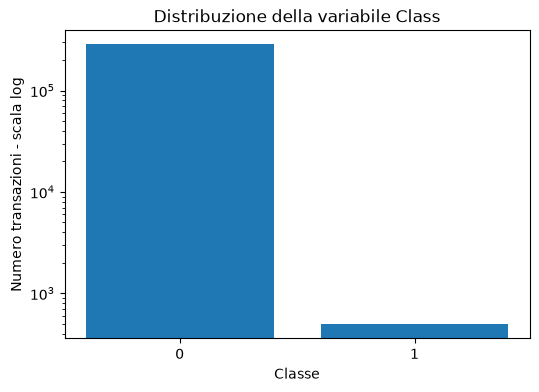

In [22]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.yscale("log")
plt.xlabel("Classe")
plt.ylabel("Numero transazioni - scala log")
plt.title("Distribuzione della variabile Class")
plt.show()

Il grafico usa la scala logaritmica perche le transazioni fraudolente sono molto meno numerose delle transazioni lecite. Questo conferma che il problema e sbilanciato.

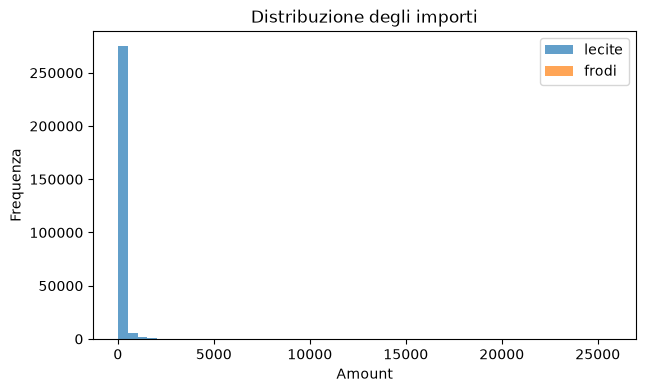

In [23]:
plt.figure(figsize=(7, 4))
plt.hist(df.loc[df["Class"] == 0, "Amount"], bins=50, alpha=0.7, label="lecite")
plt.hist(df.loc[df["Class"] == 1, "Amount"], bins=50, alpha=0.7, label="frodi")
plt.xlabel("Amount")
plt.ylabel("Frequenza")
plt.title("Distribuzione degli importi")
plt.legend()
plt.show()

In [24]:
corr_class = df.corr(numeric_only=True)["Class"].sort_values()

print("Feature con correlazione negativa piu forte:")
display(corr_class.head(5))

print("Feature con correlazione positiva piu forte:")
display(corr_class.tail(5))

Feature con correlazione negativa piu forte:


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Feature con correlazione positiva piu forte:


V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64

# 5. Preparazione dei dati

Separiamo le variabili indipendenti `X` dalla variabile target `y`. Successivamente dividiamo il dataset in training set e test set.

Usiamo `stratify=y` per mantenere nel train e nel test una proporzione simile di frodi e transazioni lecite.

In [25]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((213605, 30),
 (71202, 30),
 np.float64(0.0017274876524425926),
 np.float64(0.0017274795651807534))

In [26]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_s[:3]

array([[-1.38739851, -0.42803145, -0.31791508,  1.14134333, -0.56936473,
        -0.14684643, -0.05699602,  0.04565553,  0.2254286 ,  0.47775827,
        -0.83148856,  0.32402894,  1.03837852,  0.08333485, -0.53671508,
        -1.91604116,  0.38265298, -0.64596683,  0.1118911 ,  0.29282412,
         0.31085044,  0.06554625,  0.01754325,  0.56411242,  0.10330477,
        -1.67341115,  1.36370595,  0.1808567 ,  0.57044223,  0.08695233],
       [ 1.09929482, -1.91467867, -0.51619977, -0.29541587, -1.71028704,
        -0.29484845, -0.0796033 ,  0.09968632,  0.47250131,  0.87540693,
        -1.01337152, -0.02144243,  0.5061974 , -0.358126  ,  0.3392322 ,
        -0.20145582,  1.62686965, -1.47319702,  1.03173727, -0.5563644 ,
        -2.02686116,  0.03624888,  0.85951782, -0.06559759,  0.49857063,
         0.3100255 ,  0.77451446, -2.12766026,  0.49655482,  0.20255111],
       [ 0.89022087, -1.02997207,  0.9638046 , -0.35433344, -1.09461866,
         1.42297067, -0.29345662, -0.88814089, -3

# 6. Metodi non supervisionati per anomaly detection

In questa sezione vengono provati tre metodi richiesti dal task:

- Modified Z-score basato su MAD;
- Isolation Forest;
- Local Outlier Factor.

Questi metodi vengono trattati come confronto preliminare. Non usano la variabile target per imparare direttamente cosa sia una frode. La target viene usata solo dopo, per valutare il risultato.

In [27]:
def mad(arr):
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def evaluate_anomaly_method(name, y_true, y_pred):
    return {
        "metodo": name,
        "precision_frode": precision_score(y_true, y_pred, zero_division=0),
        "recall_frode": recall_score(y_true, y_pred, zero_division=0),
        "f1_frode": f1_score(y_true, y_pred, zero_division=0),
        "anomalie_predette": int(np.sum(y_pred))
    }

In [29]:
train_df = X_train.copy()
train_df["Class"] = y_train.values

sample_size = min(10000, len(train_df))

normal_df = train_df[train_df["Class"] == 0]
fraud_df = train_df[train_df["Class"] == 1]

n_fraud = min(len(fraud_df), max(1, int(sample_size * len(fraud_df) / len(train_df))))
n_normal = sample_size - n_fraud

sample_df = pd.concat([
    normal_df.sample(n=n_normal, random_state=42),
    fraud_df.sample(n=n_fraud, random_state=42)
]).sample(frac=1, random_state=42)

X_sample = sample_df.drop(columns=["Class"])
y_sample = sample_df["Class"]

scaler_unsup = StandardScaler()
X_sample_s = scaler_unsup.fit_transform(X_sample)

contamination = y_sample.mean()
sample_df.shape, y_sample.value_counts(), contamination

((10000, 31),
 Class
 0    9983
 1      17
 Name: count, dtype: int64,
 np.float64(0.0017))

In [30]:
# 1. Modified Z-score con MAD sull'importo della transazione
amount_med = np.median(X_sample["Amount"])
amount_mad = mad(X_sample["Amount"])

modified_z = 0.6745 * (X_sample["Amount"] - amount_med) / (amount_mad + 1e-9)
pred_mad = (modified_z.abs() > 3.5).astype(int)

print(classification_report(y_sample, pred_mad, target_names=["lecita", "frode"]))
pd.DataFrame(
    confusion_matrix(y_sample, pred_mad),
    index=["true_lecita", "true_frode"],
    columns=["pred_lecita", "pred_frode"]
)

              precision    recall  f1-score   support

      lecita       1.00      0.85      0.92      9983
       frode       0.00      0.18      0.00        17

    accuracy                           0.84     10000
   macro avg       0.50      0.51      0.46     10000
weighted avg       1.00      0.84      0.91     10000



,pred_lecita,pred_frode
true_lecita,8437,1546
true_frode,14,3


In [31]:
# 2. Isolation Forest
iso = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)
pred_iso_raw = iso.fit_predict(X_sample_s)
pred_iso = np.where(pred_iso_raw == -1, 1, 0)

print(classification_report(y_sample, pred_iso, target_names=["lecita", "frode"]))
pd.DataFrame(
    confusion_matrix(y_sample, pred_iso),
    index=["true_lecita", "true_frode"],
    columns=["pred_lecita", "pred_frode"]
)

              precision    recall  f1-score   support

      lecita       1.00      1.00      1.00      9983
       frode       0.35      0.35      0.35        17

    accuracy                           1.00     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       1.00      1.00      1.00     10000



,pred_lecita,pred_frode
true_lecita,9972,11
true_frode,11,6


In [32]:
# 3. Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, n_jobs=-1)
pred_lof_raw = lof.fit_predict(X_sample_s)
pred_lof = np.where(pred_lof_raw == -1, 1, 0)

print(classification_report(y_sample, pred_lof, target_names=["lecita", "frode"]))
pd.DataFrame(
    confusion_matrix(y_sample, pred_lof),
    index=["true_lecita", "true_frode"],
    columns=["pred_lecita", "pred_frode"]
)

              precision    recall  f1-score   support

      lecita       1.00      1.00      1.00      9983
       frode       0.65      0.65      0.65        17

    accuracy                           1.00     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       1.00      1.00      1.00     10000



,pred_lecita,pred_frode
true_lecita,9977,6
true_frode,6,11


In [33]:
unsup_results = pd.DataFrame([
    evaluate_anomaly_method("MAD su Amount", y_sample, pred_mad),
    evaluate_anomaly_method("Isolation Forest", y_sample, pred_iso),
    evaluate_anomaly_method("Local Outlier Factor", y_sample, pred_lof)
]).sort_values("f1_frode", ascending=False)

unsup_results

,metodo,precision_frode,recall_frode,f1_frode,anomalie_predette
2,Local Outlier Factor,0.647059,0.647059,0.647059,17
1,Isolation Forest,0.352941,0.352941,0.352941,17
0,MAD su Amount,0.001937,0.176471,0.003831,1549


# 7. Modello supervisionato: regressione logistica

Poiche nel dataset e disponibile la variabile target `Class`, il problema puo essere affrontato anche con un modello supervisionato. Il modello scelto e la regressione logistica, perche e semplice e adatta alla classificazione binaria.

Uso `class_weight='balanced'` per dare piu peso alla classe minoritaria.

In [34]:
logreg = LogisticRegression(class_weight="balanced", max_iter=3500, random_state=42)
logreg.fit(X_train_s, y_train)

pred_log = logreg.predict(X_test_s)
acc_log = accuracy_score(y_test, pred_log)
acc_log

0.9768405381871296

In [35]:
print(classification_report(y_test, pred_log, target_names=["lecita", "frode"]))

pd.DataFrame(
    confusion_matrix(y_test, pred_log),
    index=["true_lecita", "true_frode"],
    columns=["pred_lecita", "pred_frode"]
)

              precision    recall  f1-score   support

      lecita       1.00      0.98      0.99     71079
       frode       0.06      0.89      0.12       123

    accuracy                           0.98     71202
   macro avg       0.53      0.93      0.55     71202
weighted avg       1.00      0.98      0.99     71202



,pred_lecita,pred_frode
true_lecita,69444,1635
true_frode,14,109


# 8. Ottimizzazione del modello

Ottimizziamo il parametro `C` della regressione logistica con `GridSearchCV`. La metrica scelta e `f1`, piu adatta dell'accuracy quando le classi sono sbilanciate.

In [36]:
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=3500, random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_s, y_train)
grid.best_params_, grid.best_score_

({'C': 0.01}, np.float64(0.12333441875134593))

In [37]:
results_df = pd.DataFrame(grid.cv_results_)
results_df[["param_C", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False)

,param_C,mean_test_score,std_test_score
0,0.01,0.123334,0.006055
1,0.10,0.120759,0.004465
2,1.00,0.119920,0.004038
3,10.00,0.119850,0.003929


In [42]:
best_logreg = grid.best_estimator_
pred_best = best_logreg.predict(X_test_s)

acc_best = accuracy_score(y_test, pred_best)
acc_best

0.9774865874554085

In [41]:
best_logreg = grid.best_estimator_
pred_best = best_logreg.predict(X_test_s)

print(classification_report(y_test, pred_best, target_names=["lecita", "frode"]))

cm_best = confusion_matrix(y_test, pred_best)
pd.DataFrame(
    cm_best,
    index=["true_lecita", "true_frode"],
    columns=["pred_lecita", "pred_frode"]
)

              precision    recall  f1-score   support

      lecita       1.00      0.98      0.99     71079
       frode       0.06      0.89      0.12       123

    accuracy                           0.98     71202
   macro avg       0.53      0.93      0.55     71202
weighted avg       1.00      0.98      0.99     71202



,pred_lecita,pred_frode
true_lecita,69490,1589
true_frode,14,109


# 9. Confronto finale

Riassumiamo i risultati principali. Nei problemi sbilanciati e importante guardare soprattutto le metriche della classe frode.

In [40]:
supervised_result = pd.DataFrame({
    "metodo": ["Logistic Regression ottimizzata"],
    "precision_frode": [precision_score(y_test, pred_best, zero_division=0)],
    "recall_frode": [recall_score(y_test, pred_best, zero_division=0)],
    "f1_frode": [f1_score(y_test, pred_best, zero_division=0)],
    "anomalie_predette": [int(np.sum(pred_best))]
})

pd.concat([unsup_results, supervised_result], ignore_index=True)

,metodo,precision_frode,recall_frode,f1_frode,anomalie_predette
0,Local Outlier Factor,0.647059,0.647059,0.647059,17
1,Isolation Forest,0.352941,0.352941,0.352941,17
2,MAD su Amount,0.001937,0.176471,0.003831,1549
3,Logistic Regression ottimizzata,0.064193,0.886179,0.119714,1698


# 10. Conclusioni

Il progetto ha mostrato due modi per affrontare il problema:

1. metodi non supervisionati di anomaly detection, utili quando non si hanno etichette;
2. modello supervisionato, utile quando la variabile target e disponibile.

I metodi non supervisionati cercano transazioni anomale, ma non sempre anomalia significa frode. La regressione logistica usa invece direttamente le etichette e quindi impara a distinguere le due classi.

Il limite principale del progetto e che molte variabili sono componenti PCA (`V1`-`V28`), quindi sono difficili da interpretare dal punto di vista pratico. Inoltre il dataset e fortemente sbilanciato, quindi l'accuracy non basta per valutare il modello.